In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# Project directories
DATA_DIR = r"E:\Pyhton code\Data Sets\new dataset"

TRAIN_PATH = os.path.join(DATA_DIR, "train.jsonl")
TEST_PATH = os.path.join(DATA_DIR, "test.jsonl")
GLOVE_PATH = os.path.join(DATA_DIR, "glove.6B.50d.txt")

print("Train file :", TRAIN_PATH)
print("Test file  :", TEST_PATH)
print("GloVe file :", GLOVE_PATH)

Train file : E:\Pyhton code\Data Sets\new dataset\train.jsonl
Test file  : E:\Pyhton code\Data Sets\new dataset\test.jsonl
GloVe file : E:\Pyhton code\Data Sets\new dataset\glove.6B.50d.txt


In [5]:
#check file exist
files = {
    "Train dataset": TRAIN_PATH,
    "Test dataset": TEST_PATH,
    "GloVe embeddings": GLOVE_PATH
}

for name, path in files.items():
    exists = os.path.exists(path)
    size_mb = os.path.getsize(path) / (1024 ** 2) if exists else 0

    print(f"{name:20s} | Exists: {exists} | Size: {size_mb:.2f} MB")

Train dataset        | Exists: True | Size: 32.14 MB
Test dataset         | Exists: True | Size: 2.03 MB
GloVe embeddings     | Exists: True | Size: 163.41 MB


In [6]:
#Load AG News (train & test data)
train_df = pd.read_json(TRAIN_PATH, lines=True)
test_df = pd.read_json(TEST_PATH, lines=True)

print("Training shape:", train_df.shape)
print("Test shape    :", test_df.shape)

Training shape: (120000, 3)
Test shape    : (7600, 3)


In [7]:
#inspect the dataset
print("Training columns:")
print(train_df.columns.tolist())

print("\nFirst 5 training examples:")
display(train_df.head())

Training columns:
['label', 'title', 'description']

First 5 training examples:


,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [8]:
#check missing values
print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in test data:")
print(test_df.isnull().sum())

Missing values in training data:
label          0
title          0
description    0
dtype: int64

Missing values in test data:
label          0
title          0
description    0
dtype: int64


In [9]:
#understand the labels
print("Training label distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nTest label distribution:")
print(test_df["label"].value_counts().sort_index())

Training label distribution:
label
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64

Test label distribution:
label
1    1900
2    1900
3    1900
4    1900
Name: count, dtype: int64


In [10]:
#Convert labels to readable names
label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

train_df["category"] = train_df["label"].map(label_map)
test_df["category"] = test_df["label"].map(label_map)

print(train_df[["label", "category"]].drop_duplicates().sort_values("label"))

     label  category
492      1     World
448      2    Sports
0        3  Business
78       4  Sci/Tech


In [11]:
#Combine title and description
train_df["text"] = (
    train_df["title"].fillna("") + ". " +
    train_df["description"].fillna("")
)

test_df["text"] = (
    test_df["title"].fillna("") + ". " +
    test_df["description"].fillna("")
)

print(train_df["text"].iloc[0])

Wall St. Bears Claw Back Into the Black (Reuters). Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


In [12]:
#Basic text cleaning
def clean_text(text):
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Keep letters, numbers and spaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

print("Original:")
print(train_df["text"].iloc[0])

print("\nCleaned:")
print(train_df["clean_text"].iloc[0])

Original:
Wall St. Bears Claw Back Into the Black (Reuters). Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Cleaned:
wall st bears claw back into the black reuters reuters short sellers wall street s dwindling band of ultra cynics are seeing green again


In [13]:
#Basic dataset statistics
train_df["word_count"] = train_df["clean_text"].str.split().str.len()
test_df["word_count"] = test_df["clean_text"].str.split().str.len()

print("Training word-count statistics:")
print(train_df["word_count"].describe())

print("\nTest word-count statistics:")
print(test_df["word_count"].describe())

Training word-count statistics:
count    120000.000000
mean         39.470567
std          10.893120
min          12.000000
25%          33.000000
50%          39.000000
75%          45.000000
max         181.000000
Name: word_count, dtype: float64

Test word-count statistics:
count    7600.000000
mean       39.282105
std        10.851673
min        14.000000
25%        33.000000
50%        39.000000
75%        44.000000
max       145.000000
Name: word_count, dtype: float64


In [14]:
#Read the GloVe file
word_to_vec = {}

with open(GLOVE_PATH, "r", encoding="utf-8") as f:
    for line in f:
        values = line.rstrip().split()
        
        word = values[0]
        vector = np.asarray(values[1:], dtype=np.float32)
        
        word_to_vec[word] = vector

print("Vocabulary size:", len(word_to_vec))

Vocabulary size: 400000


In [15]:
#Check embedding dimensions
sample_word = "king"

print("Word:", sample_word)
print("Vector:", word_to_vec[sample_word])
print("Vector dimension:", len(word_to_vec[sample_word]))

Word: king
Vector: [ 0.50451   0.68607  -0.59517  -0.022801  0.60046  -0.13498  -0.08813
  0.47377  -0.61798  -0.31012  -0.076666  1.493    -0.034189 -0.98173
  0.68229   0.81722  -0.51874  -0.31503  -0.55809   0.66421   0.1961
 -0.13495  -0.11476  -0.30344   0.41177  -2.223    -1.0756   -1.0783
 -0.34354   0.33505   1.9927   -0.04234  -0.64319   0.71125   0.49159
  0.16754   0.34344  -0.25663  -0.8523    0.1661    0.40102   1.1685
 -1.0137   -0.21585  -0.15155   0.78321  -0.91241  -1.6106   -0.64426
 -0.51042 ]
Vector dimension: 50


In [16]:
#inspect a few embeddings
sample_words = [
    "king",
    "queen",
    "man",
    "woman",
    "computer",
    "football"
]

for word in sample_words:
    if word in word_to_vec:
        print(f"{word:10s} → {word_to_vec[word][:10]}")

king       → [ 0.50451   0.68607  -0.59517  -0.022801  0.60046  -0.13498  -0.08813
  0.47377  -0.61798  -0.31012 ]
queen      → [ 0.37854   1.8233   -1.2648   -0.1043    0.35829   0.60029  -0.17538
  0.83767  -0.056798 -0.75795 ]
man        → [-0.094386  0.43007  -0.17224  -0.45529   1.6447    0.40335  -0.37263
  0.25071  -0.10588   0.10778 ]
woman      → [-0.18153  0.64827 -0.5821  -0.49451  1.5415   1.345   -0.43305  0.58059
  0.35556 -0.25184]
computer   → [ 0.079084 -0.81504   1.7901    0.91653   0.10797  -0.55628  -0.84427
 -1.4951    0.13418   0.63627 ]
football   → [-1.8209   0.70094 -1.1403   0.34363 -0.42266 -0.92479 -1.3942   0.28512
 -0.78416 -0.52579]


In [17]:
#Tokenize articles
def tokenize(text):
    return text.split()


sample_tokens = tokenize(train_df["clean_text"].iloc[0])

print(sample_tokens)

['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'short', 'sellers', 'wall', 'street', 's', 'dwindling', 'band', 'of', 'ultra', 'cynics', 'are', 'seeing', 'green', 'again']


In [18]:
#check OOV words in one article
tokens = tokenize(train_df["clean_text"].iloc[0])

known_words = [
    word for word in tokens
    if word in word_to_vec
]

unknown_words = [
    word for word in tokens
    if word not in word_to_vec
]

print("Total words :", len(tokens))
print("Known words :", len(known_words))
print("Unknown     :", len(unknown_words))

print("\nUnknown words:")
print(unknown_words)

Total words : 24
Known words : 24
Unknown     : 0

Unknown words:
[]


In [19]:
#calculate coverage on a sample
sample_size = 10000

sample_texts = train_df["clean_text"].iloc[:sample_size]

total_tokens = 0
known_tokens = 0

for text in sample_texts:
    tokens = text.split()
    
    total_tokens += len(tokens)
    known_tokens += sum(
        1 for token in tokens
        if token in word_to_vec
    )

coverage = known_tokens / total_tokens

print(f"Total tokens checked : {total_tokens:,}")
print(f"Known tokens         : {known_tokens:,}")
print(f"GloVe coverage       : {coverage:.2%}")

Total tokens checked : 402,990
Known tokens         : 401,027
GloVe coverage       : 99.51%


In [20]:
#word embedding lookup
def get_word_vector(word):
    
    return word_to_vec.get(word)

vector = get_word_vector("king")

print("Vector found:", vector is not None)

if vector is not None:
    print("Shape:", vector.shape)

Vector found: True
Shape: (50,)


In [21]:
#Cosine Similarity
def cosine_similarity(vec1, vec2):
    denominator = (
        np.linalg.norm(vec1) *
        np.linalg.norm(vec2)
    )
    
    if denominator == 0:
        return 0.0
    
    return np.dot(vec1, vec2) / denominator

In [22]:
#Test word similarity
pairs = [
    ("king", "queen"),
    ("computer", "technology"),
    ("football", "soccer"),
    ("king", "banana"),
    ("computer", "football")
]

for word1, word2 in pairs:
    similarity = cosine_similarity(
        word_to_vec[word1],
        word_to_vec[word2]
    )
    
    print(
        f"{word1:12s} ↔ {word2:12s} "
        f"= {similarity:.4f}"
    )

king         ↔ queen        = 0.7839
computer     ↔ technology   = 0.8526
football     ↔ soccer       = 0.8965
king         ↔ banana       = 0.2207
computer     ↔ football     = 0.2899


In [23]:
#create vocablury indices
words_list = list(word_to_vec.keys())

word_to_index = {
    word: idx
    for idx, word in enumerate(words_list)
}

index_to_word = {
    idx: word
    for idx, word in enumerate(words_list)
}

print("Vocabulary size:", len(words_list))
print("First 10 words:", words_list[:10])

Vocabulary size: 400000
First 10 words: ['the', ',', '.', 'of', 'to', 'and', 'in', 'a', '"', "'s"]


In [24]:
#Create embedding matrix
embedding_matrix = np.vstack([
    word_to_vec[word]
    for word in words_list
])

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (400000, 50)


In [25]:
#create artifcat directory
ARTIFACT_DIR = "../artifacts"

os.makedirs(ARTIFACT_DIR, exist_ok=True)

print("Artifact directory ready:", ARTIFACT_DIR)

Artifact directory ready: ../artifacts


In [26]:
#save the embedding matrix
np.save(
    os.path.join(
        ARTIFACT_DIR,
        "glove_50d_matrix.npy"
    ),
    embedding_matrix
)

print("Embedding matrix saved.")

Embedding matrix saved.


In [27]:
#save vocablury
import pickle

with open(
    os.path.join(
        ARTIFACT_DIR,
        "glove_vocab.pkl"
    ),
    "wb"
) as f:
    pickle.dump(words_list, f)

print("Vocabulary saved.")

Vocabulary saved.


In [28]:
#verify everything
print("=" * 60)
print("PHASE 1 SANITY CHECK")
print("=" * 60)

print(f"Train samples       : {len(train_df):,}")
print(f"Test samples        : {len(test_df):,}")
print(f"GloVe vocabulary    : {len(word_to_vec):,}")
print(f"Embedding dimension : {embedding_matrix.shape[1]}")
print(f"Embedding matrix    : {embedding_matrix.shape}")

print("\nCategories:")
print(train_df["category"].value_counts())

print("\nRequired words:")
for word in ["king", "queen", "man", "woman", "computer"]:
    print(f"{word:10s} → {word in word_to_vec}")

print("\nPhase 1 completed successfully.")


PHASE 1 SANITY CHECK
Train samples       : 120,000
Test samples        : 7,600
GloVe vocabulary    : 400,000
Embedding dimension : 50
Embedding matrix    : (400000, 50)

Categories:
category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64

Required words:
king       → True
queen      → True
man        → True
woman      → True
computer   → True

Phase 1 completed successfully.


# Building Document Embeddings

In [29]:
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("GloVe vocabulary:", len(word_to_vec))
print("Embedding dimension:", embedding_matrix.shape[1])

Train shape: (120000, 7)
Test shape : (7600, 7)
GloVe vocabulary: 400000
Embedding dimension: 50


In [30]:
#create a faster vector lookup
embedding_dim = embedding_matrix.shape[1]

print("Embedding dimension:", embedding_dim)

Embedding dimension: 50


In [ ]:
#Create a function for mean word embeddings
def document_embedding_mean(text, word_to_vec, embedding_dim=50):
    
    tokens = text.split()
    
    vectors = [
        word_to_vec[token]
        for token in tokens
        if token in word_to_vec
    ]
    
    if len(vectors) == 0:
        return np.zeros(embedding_dim, dtype=np.float32)
    
    return np.mean(vectors, axis=0).astype(np.float32)

In [32]:
#test mean embedding
sample_text = train_df["clean_text"].iloc[0]

sample_embedding = document_embedding_mean(
    sample_text,
    word_to_vec,
    embedding_dim
)

print("Document embedding shape:", sample_embedding.shape)
print("First 10 values:")
print(sample_embedding[:10])

Document embedding shape: (50,)
First 10 values:
[ 0.05364504  0.19114454  0.29287198 -0.38502833  0.35669315  0.02781025
 -0.6497343  -0.16462344 -0.13283768 -0.0718199 ]


In [33]:
#check document coverage
def document_coverage(text, word_to_vec):
    tokens = text.split()
    
    if len(tokens) == 0:
        return 0.0
    
    known = sum(
        1 for token in tokens
        if token in word_to_vec
    )
    
    return known / len(tokens)


coverage_sample = train_df["clean_text"].iloc[:10000].apply(
    lambda x: document_coverage(x, word_to_vec)
)

print("Average GloVe coverage:",
      f"{coverage_sample.mean():.2%}")

print("Minimum coverage:",
      f"{coverage_sample.min():.2%}")

print("Median coverage:",
      f"{coverage_sample.median():.2%}")

Average GloVe coverage: 99.56%
Minimum coverage: 82.14%
Median coverage: 100.00%


In [34]:
#Add coverage information
train_df["glove_coverage"] = train_df["clean_text"].apply(
    lambda x: document_coverage(x, word_to_vec)
)

test_df["glove_coverage"] = test_df["clean_text"].apply(
    lambda x: document_coverage(x, word_to_vec)
)

print(
    "Training average coverage:",
    f"{train_df['glove_coverage'].mean():.2%}"
)

print(
    "Test average coverage:",
    f"{test_df['glove_coverage'].mean():.2%}"
)

Training average coverage: 99.54%
Test average coverage: 99.58%


In [35]:
#create training document embeddings
train_mean_embeddings = np.vstack([
    document_embedding_mean(
        text,
        word_to_vec,
        embedding_dim
    )
    for text in train_df["clean_text"]
])

print("Training embedding shape:",
      train_mean_embeddings.shape)

Training embedding shape: (120000, 50)


In [36]:
#create test document embeddings
test_mean_embeddings = np.vstack([
    document_embedding_mean(
        text,
        word_to_vec,
        embedding_dim
    )
    for text in test_df["clean_text"]
])

print("Test embedding shape:",
      test_mean_embeddings.shape)

Test embedding shape: (7600, 50)


In [37]:
#inspect document vectors
print("First training document vector:")
print(train_mean_embeddings[0])

print("\nVector norm:",
      np.linalg.norm(train_mean_embeddings[0]))

First training document vector:
[ 0.05364504  0.19114454  0.29287198 -0.38502833  0.35669315  0.02781025
 -0.6497343  -0.16462344 -0.13283768 -0.0718199  -0.04768587 -0.05581479
 -0.27719375  0.10826147 -0.0138439   0.19295973  0.0611405  -0.3404235
 -0.5360517  -0.35717312  0.10211039 -0.07883742  0.07207692 -0.02877933
 -0.12097359 -1.0501503  -0.5370005   0.26244473  0.10493063 -0.17359768
  2.418359    0.09932967  0.3070458  -0.08425658 -0.10980041 -0.09801149
 -0.08486211 -0.21189326  0.07916976 -0.3828665  -0.02288929 -0.01715405
 -0.15717137  0.04327973  0.1766792   0.01254696 -0.01020264 -0.32178053
  0.00257575 -0.28127936]

Vector norm: 3.0831456


In [38]:
#compare two documents
similarity = cosine_similarity(
    train_mean_embeddings[0],
    train_mean_embeddings[1]
)

print("Similarity between article 1 and article 2:",
      round(similarity, 4))

Similarity between article 1 and article 2: 0.8912


In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("TfidfVectorizer imported successfully.")

TfidfVectorizer imported successfully.


In [40]:
#Build TF-IDF vocablary
tfidf_vectorizer = TfidfVectorizer(
    max_features=50000,
    min_df=2,
    max_df=0.95,
    token_pattern=r"(?u)\b[a-zA-Z0-9]+\b"
)

train_tfidf = tfidf_vectorizer.fit_transform(
    train_df["clean_text"]
)

test_tfidf = tfidf_vectorizer.transform(
    test_df["clean_text"]
)

print("TF-IDF training shape:", train_tfidf.shape)
print("TF-IDF test shape    :", test_tfidf.shape)

TF-IDF training shape: (120000, 41941)
TF-IDF test shape    : (7600, 41941)


In [42]:
#inspect TF-IDF words to GloVe vectors
tfidf_words = tfidf_vectorizer.get_feature_names_out()

print("Number of TF-IDF words:", len(tfidf_words))
print("\nFirst 30 words:")
print(tfidf_words[:30])

Number of TF-IDF words: 41941

First 30 words:
['0' '00' '000' '000km' '000m' '000metres' '000mph' '000th' '001'
 '001107539' '0013' '002' '005930' '007' '01' '010' '013' '02' '025' '027'
 '028' '029' '03' '033' '038' '04' '042' '046' '048' '04q4']


In [43]:
#Map TF-IDF words to GloVe vectors
tfidf_glove_words = []
tfidf_glove_vectors = []

for word in tfidf_words:
    if word in word_to_vec:
        tfidf_glove_words.append(word)
        tfidf_glove_vectors.append(word_to_vec[word])

tfidf_glove_vectors = np.asarray(
    tfidf_glove_vectors,
    dtype=np.float32
)

print("TF-IDF vocabulary:", len(tfidf_words))
print("Words with GloVe vectors:", len(tfidf_glove_words))
print("GloVe vector matrix shape:",
      tfidf_glove_vectors.shape)

TF-IDF vocabulary: 41941
Words with GloVe vectors: 40279
GloVe vector matrix shape: (40279, 50)


In [44]:
#Create aligned vocabulary indices
tfidf_vocab_to_index = {
    word: idx
    for idx, word in enumerate(tfidf_glove_words)
}

print("Aligned vocabulary size:",
      len(tfidf_vocab_to_index))

Aligned vocabulary size: 40279


In [45]:
#create the aligned TF-IDF matrix
aligned_indices = [
    tfidf_vectorizer.vocabulary_[word]
    for word in tfidf_glove_words
]

train_tfidf_aligned = train_tfidf[:, aligned_indices]
test_tfidf_aligned = test_tfidf[:, aligned_indices]

print("Aligned train TF-IDF shape:",
      train_tfidf_aligned.shape)

print("Aligned test TF-IDF shape:",
      test_tfidf_aligned.shape)

Aligned train TF-IDF shape: (120000, 40279)
Aligned test TF-IDF shape: (7600, 40279)


In [46]:
#Generate TF-IDF weighted document
train_tfidf_embeddings = (
    train_tfidf_aligned @ tfidf_glove_vectors
)

test_tfidf_embeddings = (
    test_tfidf_aligned @ tfidf_glove_vectors
)

train_tfidf_embeddings = np.asarray(
    train_tfidf_embeddings,
    dtype=np.float32
)

test_tfidf_embeddings = np.asarray(
    test_tfidf_embeddings,
    dtype=np.float32
)

print(
    "Train TF-IDF embedding shape:",
    train_tfidf_embeddings.shape
)

print(
    "Test TF-IDF embedding shape:",
    test_tfidf_embeddings.shape
)

Train TF-IDF embedding shape: (120000, 50)
Test TF-IDF embedding shape: (7600, 50)


In [47]:
#compare the two representation
print("Mean GloVe:")
print(train_mean_embeddings[0][:10])

print("\nTF-IDF weighted GloVe:")
print(train_tfidf_embeddings[0][:10])

Mean GloVe:
[ 0.05364504  0.19114454  0.29287198 -0.38502833  0.35669315  0.02781025
 -0.6497343  -0.16462344 -0.13283768 -0.0718199 ]

TF-IDF weighted GloVe:
[-0.02062016  0.47511968  1.1833847  -2.227345    1.3548638   0.22834694
 -2.8228953  -0.53453773 -0.6597087   0.25495034]


In [48]:
#Normalize Document Embeddings
from sklearn.preprocessing import normalize

train_mean_embeddings_norm = normalize(
    train_mean_embeddings,
    norm="l2"
)

test_mean_embeddings_norm = normalize(
    test_mean_embeddings,
    norm="l2"
)

train_tfidf_embeddings_norm = normalize(
    train_tfidf_embeddings,
    norm="l2"
)

test_tfidf_embeddings_norm = normalize(
    test_tfidf_embeddings,
    norm="l2"
)

print("Normalization completed.")

Normalization completed.


In [49]:
#compare similarity using both approaches
doc_a = 0
doc_b = 1

mean_similarity = np.dot(
    train_mean_embeddings_norm[doc_a],
    train_mean_embeddings_norm[doc_b]
)

tfidf_similarity = np.dot(
    train_tfidf_embeddings_norm[doc_a],
    train_tfidf_embeddings_norm[doc_b]
)

print("Article 1 vs Article 2")

print(
    "Mean GloVe similarity:",
    round(float(mean_similarity), 4)
)

print(
    "TF-IDF GloVe similarity:",
    round(float(tfidf_similarity), 4)
)

Article 1 vs Article 2
Mean GloVe similarity: 0.8912
TF-IDF GloVe similarity: 0.8195


In [50]:
#display sample articles
for i in range(5):
    print("=" * 80)
    print("ARTICLE", i)
    print("Category:", train_df["category"].iloc[i])
    print("Title:", train_df["title"].iloc[i])
    print("Text:", train_df["description"].iloc[i])

ARTICLE 0
Category: Business
Title: Wall St. Bears Claw Back Into the Black (Reuters)
Text: Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
ARTICLE 1
Category: Business
Title: Carlyle Looks Toward Commercial Aerospace (Reuters)
Text: Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
ARTICLE 2
Category: Business
Title: Oil and Economy Cloud Stocks' Outlook (Reuters)
Text: Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.
ARTICLE 3
Category: Business
Title: Iraq Halts Oil Exports from Main Southern Pipeline (Reuters)
Text: Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel m

In [51]:
#Find similarity between sample articles
sample_indices = [0, 1, 2, 3, 4]

sample_similarity = (
    train_mean_embeddings_norm[sample_indices]
    @ train_mean_embeddings_norm[sample_indices].T
)

print("Mean GloVe similarity matrix:")
print(np.round(sample_similarity, 3))

Mean GloVe similarity matrix:
[[1.    0.891 0.893 0.802 0.888]
 [0.891 1.    0.919 0.9   0.919]
 [0.893 0.919 1.    0.892 0.964]
 [0.802 0.9   0.892 1.    0.923]
 [0.888 0.919 0.964 0.923 1.   ]]


In [52]:
#save mean embeddings
np.save(
    "../artifacts/train_mean_embeddings.npy",
    train_mean_embeddings_norm
)

np.save(
    "../artifacts/test_mean_embeddings.npy",
    test_mean_embeddings_norm
)

print("Mean embedding artifacts saved.")

Mean embedding artifacts saved.


In [53]:
#save TF-IDF embeddings
np.save(
    "../artifacts/train_tfidf_embeddings.npy",
    train_tfidf_embeddings_norm
)

np.save(
    "../artifacts/test_tfidf_embeddings.npy",
    test_tfidf_embeddings_norm
)

print("TF-IDF embedding artifacts saved.")

TF-IDF embedding artifacts saved.


In [54]:
#save TF-IDF vectorizer
import pickle

with open(
    "../artifacts/tfidf_vectorizer.pkl",
    "wb"
) as f:
    pickle.dump(tfidf_vectorizer, f)

print("TF-IDF vectorizer saved.")

TF-IDF vectorizer saved.


In [55]:
print("=" * 65)
print("PHASE 2 SANITY CHECK")
print("=" * 65)

print(f"Training articles           : {len(train_df):,}")
print(f"Test articles               : {len(test_df):,}")

print(
    f"Mean train embeddings       : "
    f"{train_mean_embeddings_norm.shape}"
)

print(
    f"Mean test embeddings        : "
    f"{test_mean_embeddings_norm.shape}"
)

print(
    f"TF-IDF train embeddings     : "
    f"{train_tfidf_embeddings_norm.shape}"
)

print(
    f"TF-IDF test embeddings      : "
    f"{test_tfidf_embeddings_norm.shape}"
)

print(
    f"TF-IDF vocabulary           : "
    f"{len(tfidf_words):,}"
)

print(
    f"Embedding dimension         : "
    f"{embedding_dim}"
)

print("\nSaved artifacts:")
print("✓ train_mean_embeddings.npy")
print("✓ test_mean_embeddings.npy")
print("✓ train_tfidf_embeddings.npy")
print("✓ test_tfidf_embeddings.npy")
print("✓ tfidf_vectorizer.pkl")

print("\nPhase 2 completed successfully.")

PHASE 2 SANITY CHECK
Training articles           : 120,000
Test articles               : 7,600
Mean train embeddings       : (120000, 50)
Mean test embeddings        : (7600, 50)
TF-IDF train embeddings     : (120000, 50)
TF-IDF test embeddings      : (7600, 50)
TF-IDF vocabulary           : 41,941
Embedding dimension         : 50

Saved artifacts:
✓ train_mean_embeddings.npy
✓ test_mean_embeddings.npy
✓ train_tfidf_embeddings.npy
✓ test_tfidf_embeddings.npy
✓ tfidf_vectorizer.pkl

Phase 2 completed successfully.


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [57]:
#load artifacts
train_mean_embeddings = np.load(
    "../artifacts/train_mean_embeddings.npy"
)

test_mean_embeddings = np.load(
    "../artifacts/test_mean_embeddings.npy"
)

train_tfidf_embeddings = np.load(
    "../artifacts/train_tfidf_embeddings.npy"
)

test_tfidf_embeddings = np.load(
    "../artifacts/test_tfidf_embeddings.npy"
)

print("Mean train:", train_mean_embeddings.shape)
print("Mean test :", test_mean_embeddings.shape)

print("TF-IDF train:", train_tfidf_embeddings.shape)
print("TF-IDF test :", test_tfidf_embeddings.shape)

Mean train: (120000, 50)
Mean test : (7600, 50)
TF-IDF train: (120000, 50)
TF-IDF test : (7600, 50)


In [59]:
#load labels
train_df = pd.read_json(
    r"E:\Pyhton code\Data Sets\new dataset\train.jsonl",
    lines=True
)

test_df = pd.read_json(
    r"E:\Pyhton code\Data Sets\new dataset\test.jsonl",
    lines=True
)

label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

y = train_df["label"].values
y_test = test_df["label"].values

print("Training labels:", y.shape)
print("Test labels    :", y_test.shape)

print("\nLabel counts:")
print(pd.Series(y).value_counts().sort_index())

Training labels: (120000,)
Test labels    : (7600,)

Label counts:
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64


In [60]:
#create validation split
indices = np.arange(len(y))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print("Training samples  :", len(train_indices))
print("Validation samples:", len(val_indices))
print("Test samples      :", len(y_test))

Training samples  : 102000
Validation samples: 18000
Test samples      : 7600


In [61]:
#prepare the four datasets
X_mean_train = train_mean_embeddings[train_indices]
X_mean_val = train_mean_embeddings[val_indices]

X_tfidf_train = train_tfidf_embeddings[train_indices]
X_tfidf_val = train_tfidf_embeddings[val_indices]

y_train = y[train_indices]
y_val = y[val_indices]

print("Mean training:", X_mean_train.shape)
print("Mean validation:", X_mean_val.shape)

print("TF-IDF training:", X_tfidf_train.shape)
print("TF-IDF validation:", X_tfidf_val.shape)

Mean training: (102000, 50)
Mean validation: (18000, 50)
TF-IDF training: (102000, 50)
TF-IDF validation: (18000, 50)


In [62]:
#majority-class baseline
majority_class = pd.Series(y_train).mode()[0]

baseline_predictions = np.full(
    len(y_val),
    majority_class
)

baseline_accuracy = accuracy_score(
    y_val,
    baseline_predictions
)

baseline_f1 = f1_score(
    y_val,
    baseline_predictions,
    average="macro"
)

print("Majority class:", majority_class)
print("Baseline accuracy:", round(baseline_accuracy, 4))
print("Baseline macro F1:", round(baseline_f1, 4))

Majority class: 1
Baseline accuracy: 0.25
Baseline macro F1: 0.1


In [63]:
#train logistic regression on mean GloVe
logreg_mean = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg_mean.fit(
    X_mean_train,
    y_train
)

print("Mean GloVe Logistic Regression trained.")

Mean GloVe Logistic Regression trained.


In [64]:
#evaluate mean Glove logistic regression
mean_val_predictions = logreg_mean.predict(
    X_mean_val
)

mean_val_accuracy = accuracy_score(
    y_val,
    mean_val_predictions
)

mean_val_f1 = f1_score(
    y_val,
    mean_val_predictions,
    average="macro"
)

print("Mean GloVe Logistic Regression")
print("--------------------------------")
print("Accuracy :", round(mean_val_accuracy, 4))
print("Macro F1 :", round(mean_val_f1, 4))

Mean GloVe Logistic Regression
--------------------------------
Accuracy : 0.8823
Macro F1 : 0.8821


In [65]:
#Train TF-IDF + GloVe Logistic Regression
logreg_tfidf = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg_tfidf.fit(
    X_tfidf_train,
    y_train
)

print("TF-IDF + GloVe Logistic Regression trained.")

TF-IDF + GloVe Logistic Regression trained.


In [66]:
#Evaluate TF-IDF + GloVe Logistic Regression
tfidf_val_predictions = logreg_tfidf.predict(
    X_tfidf_val
)

tfidf_val_accuracy = accuracy_score(
    y_val,
    tfidf_val_predictions
)

tfidf_val_f1 = f1_score(
    y_val,
    tfidf_val_predictions,
    average="macro"
)

print("TF-IDF + GloVe Logistic Regression")
print("------------------------------------")
print("Accuracy :", round(tfidf_val_accuracy, 4))
print("Macro F1 :", round(tfidf_val_f1, 4))

TF-IDF + GloVe Logistic Regression
------------------------------------
Accuracy : 0.8807
Macro F1 : 0.8805


In [67]:
#Linear SVM 
svm_mean = LinearSVC(
    C=1.0,
    random_state=42
)

svm_mean.fit(
    X_mean_train,
    y_train
)

print("Mean GloVe Linear SVM trained.")

Mean GloVe Linear SVM trained.


In [68]:
#Evaluate mean GloVe SVM
svm_mean_predictions = svm_mean.predict(
    X_mean_val
)

svm_mean_accuracy = accuracy_score(
    y_val,
    svm_mean_predictions
)

svm_mean_f1 = f1_score(
    y_val,
    svm_mean_predictions,
    average="macro"
)

print("Mean GloVe Linear SVM")
print("---------------------")
print("Accuracy :", round(svm_mean_accuracy, 4))
print("Macro F1 :", round(svm_mean_f1, 4))

Mean GloVe Linear SVM
---------------------
Accuracy : 0.883
Macro F1 : 0.8827


In [69]:
#Train TF-IDF + GloVe SVM
svm_tfidf = LinearSVC(
    C=1.0,
    random_state=42
)

svm_tfidf.fit(
    X_tfidf_train,
    y_train
)

print("TF-IDF + GloVe Linear SVM trained.")

TF-IDF + GloVe Linear SVM trained.


In [70]:
#Evalute TF-IDF + GloVe SVM
svm_tfidf_predictions = svm_tfidf.predict(
    X_tfidf_val
)

svm_tfidf_accuracy = accuracy_score(
    y_val,
    svm_tfidf_predictions
)

svm_tfidf_f1 = f1_score(
    y_val,
    svm_tfidf_predictions,
    average="macro"
)

print("TF-IDF + GloVe Linear SVM")
print("-------------------------")
print("Accuracy :", round(svm_tfidf_accuracy, 4))
print("Macro F1 :", round(svm_tfidf_f1, 4))

TF-IDF + GloVe Linear SVM
-------------------------
Accuracy : 0.8819
Macro F1 : 0.8817


In [71]:
#compare all models
results = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic + Mean GloVe",
        "Logistic + TF-IDF GloVe",
        "SVM + Mean GloVe",
        "SVM + TF-IDF GloVe"
    ],
    "Accuracy": [
        baseline_accuracy,
        mean_val_accuracy,
        tfidf_val_accuracy,
        svm_mean_accuracy,
        svm_tfidf_accuracy
    ],
    "Macro F1": [
        baseline_f1,
        mean_val_f1,
        tfidf_val_f1,
        svm_mean_f1,
        svm_tfidf_f1
    ]
})

results = results.sort_values(
    "Macro F1",
    ascending=False
).reset_index(drop=True)

print(results.to_string(index=False))

                  Model  Accuracy  Macro F1
       SVM + Mean GloVe  0.883000  0.882679
  Logistic + Mean GloVe  0.882333  0.882108
     SVM + TF-IDF GloVe  0.881944  0.881699
Logistic + TF-IDF GloVe  0.880667  0.880478
      Majority Baseline  0.250000  0.100000


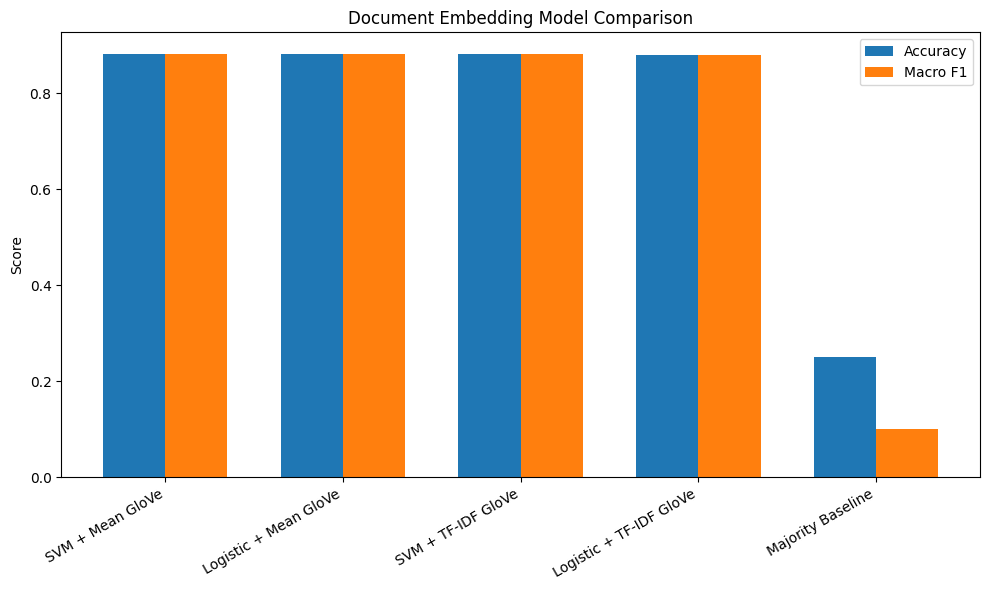

In [72]:
#plot model comparison
plt.figure(figsize=(10, 6))

x = np.arange(len(results))
width = 0.35

plt.bar(
    x - width / 2,
    results["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x + width / 2,
    results["Macro F1"],
    width,
    label="Macro F1"
)

plt.xticks(
    x,
    results["Model"],
    rotation=30,
    ha="right"
)

plt.ylabel("Score")
plt.title("Document Embedding Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
#select best configuration
best_model_name = results.iloc[0]["Model"]

print("Selected configuration:")
print(best_model_name)

Selected configuration:
SVM + Mean GloVe


In [74]:
#generate classification report
prediction_map = {
    "Logistic + Mean GloVe": mean_val_predictions,
    "Logistic + TF-IDF GloVe": tfidf_val_predictions,
    "SVM + Mean GloVe": svm_mean_predictions,
    "SVM + TF-IDF GloVe": svm_tfidf_predictions
}

selected_predictions = prediction_map[best_model_name]

print(
    classification_report(
        y_val,
        selected_predictions,
        target_names=[
            "World",
            "Sports",
            "Business",
            "Sci/Tech"
        ]
    )
)

              precision    recall  f1-score   support

       World       0.90      0.87      0.88      4500
      Sports       0.94      0.97      0.96      4500
    Business       0.84      0.85      0.84      4500
    Sci/Tech       0.85      0.84      0.85      4500

    accuracy                           0.88     18000
   macro avg       0.88      0.88      0.88     18000
weighted avg       0.88      0.88      0.88     18000



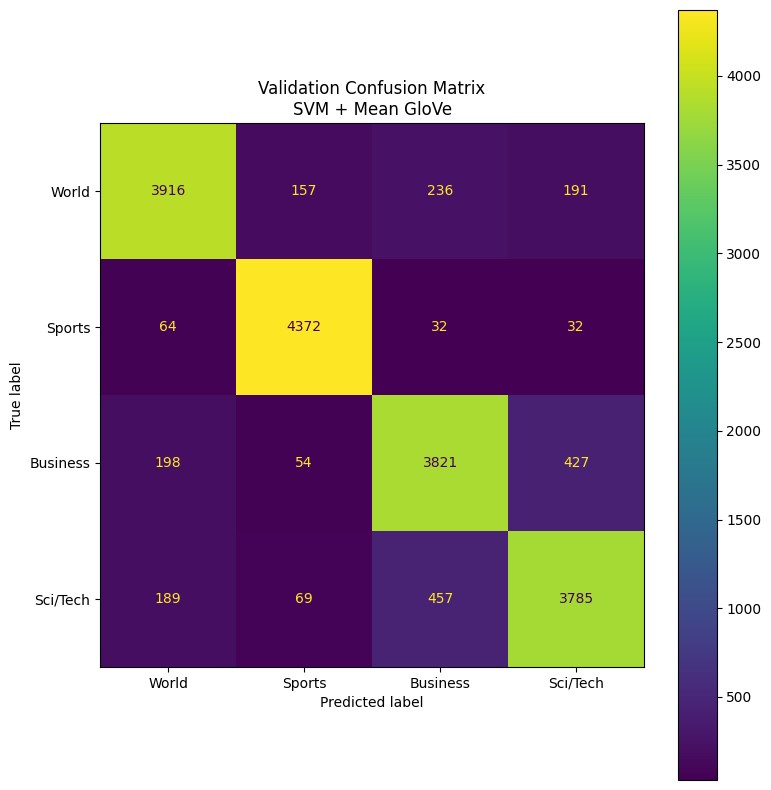

In [75]:
#confusion matrix
cm = confusion_matrix(
    y_val,
    selected_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "World",
        "Sports",
        "Business",
        "Sci/Tech"
    ]
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title(
    f"Validation Confusion Matrix\n{best_model_name}"
)

plt.tight_layout()
plt.show()

In [76]:
#validation errors
validation_df = train_df.iloc[val_indices].copy()

validation_df["true_label"] = y_val
validation_df["predicted_label"] = selected_predictions

validation_df["true_category"] = (
    validation_df["true_label"].map(label_map)
)

validation_df["predicted_category"] = (
    validation_df["predicted_label"].map(label_map)
)

errors_df = validation_df[
    validation_df["true_label"] !=
    validation_df["predicted_label"]
].copy()

print("Validation errors:", len(errors_df))
print(
    "Validation error rate:",
    f"{len(errors_df) / len(validation_df):.2%}"
)

Validation errors: 2106
Validation error rate: 11.70%


In [77]:
#inspect some errors
for _, row in errors_df.head(10).iterrows():
    print("=" * 90)
    print("TITLE:", row["title"])
    print("TRUE :", row["true_category"])
    print("PRED :", row["predicted_category"])
    print("TEXT :", row["description"])

TITLE: 'Ringback' Tones May Be Next Big Thing
TRUE : Sci/Tech
PRED : Business
TEXT : Ring tones are so yesterday. If wireless companies have their way, the next multibillion-dollar surprise in the cellular business will be "Ringback" tones.
TITLE: Yahoo #39;s Home Page Gets Functional Facelift
TRUE : Business
PRED : Sci/Tech
TEXT : Yahoo #39;s Spartan home page will look even less flashy soon, thanks to an upcoming makeover. The Web media giant offered a preview of its redesigned front page Tuesday (www.
TITLE: Greenspan on America #39;s Age Wave
TRUE : Business
PRED : Sci/Tech
TEXT : The only things you can count on in life, or so the saying goes, are death and taxes. But when it comes to economics and government budgets, perhaps the only thing that #39;s for sure is demographics.
TITLE: Ivory crackdown agreed in Africa
TRUE : Sci/Tech
PRED : World
TEXT : African countries have announced a continent-wide plan to slash ivory trading in their domestic markets.
TITLE: Kerry rebukes Bush 

In [78]:
#train final selected classifier
if best_model_name == "Logistic + Mean GloVe":
    final_model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )
    
    final_model.fit(
        train_mean_embeddings,
        y
    )
    
    final_representation = "mean"

elif best_model_name == "Logistic + TF-IDF GloVe":
    final_model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )
    
    final_model.fit(
        train_tfidf_embeddings,
        y
    )
    
    final_representation = "tfidf"

elif best_model_name == "SVM + Mean GloVe":
    final_model = LinearSVC(
        C=1.0,
        random_state=42
    )
    
    final_model.fit(
        train_mean_embeddings,
        y
    )
    
    final_representation = "mean"

elif best_model_name == "SVM + TF-IDF GloVe":
    final_model = LinearSVC(
        C=1.0,
        random_state=42
    )
    
    final_model.fit(
        train_tfidf_embeddings,
        y
    )
    
    final_representation = "tfidf"

print("Final model trained.")
print("Representation:", final_representation)

Final model trained.
Representation: mean


In [79]:
#final test evaluation
if final_representation == "mean":
    test_predictions = final_model.predict(
        test_mean_embeddings
    )
else:
    test_predictions = final_model.predict(
        test_tfidf_embeddings
    )

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro"
)

print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print("Model:", best_model_name)
print("Representation:", final_representation)
print("Test accuracy:", round(test_accuracy, 4))
print("Test macro F1:", round(test_f1, 4))

FINAL TEST RESULTS
Model: SVM + Mean GloVe
Representation: mean
Test accuracy: 0.8805
Test macro F1: 0.8803


In [80]:
#classification report
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "World",
            "Sports",
            "Business",
            "Sci/Tech"
        ]
    )
)

              precision    recall  f1-score   support

       World       0.90      0.88      0.89      1900
      Sports       0.94      0.97      0.95      1900
    Business       0.83      0.84      0.83      1900
    Sci/Tech       0.85      0.84      0.85      1900

    accuracy                           0.88      7600
   macro avg       0.88      0.88      0.88      7600
weighted avg       0.88      0.88      0.88      7600



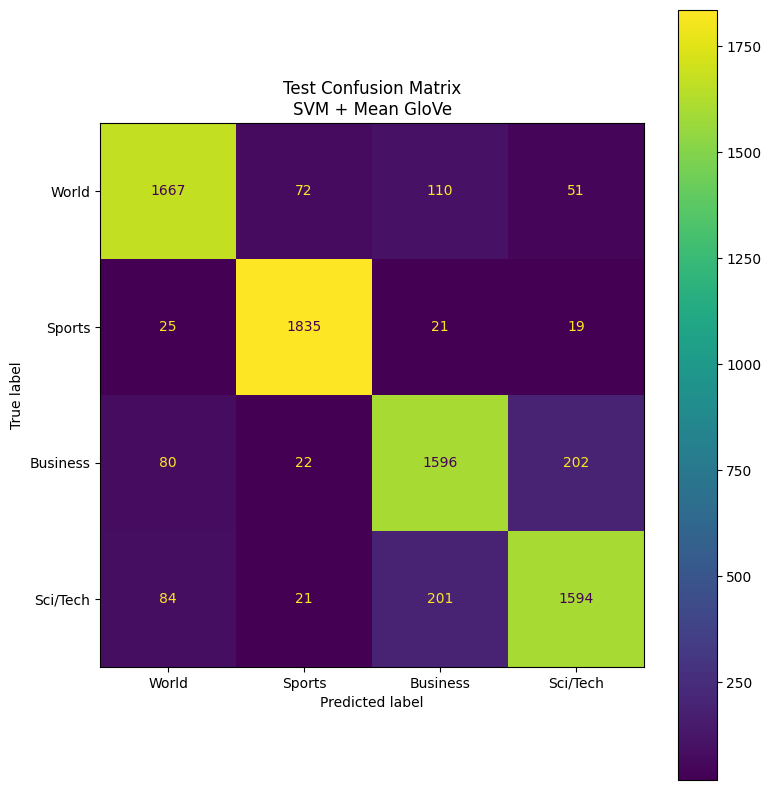

In [81]:
#confusion matrix
cm_test = confusion_matrix(
    y_test,
    test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=[
        "World",
        "Sports",
        "Business",
        "Sci/Tech"
    ]
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title(
    f"Test Confusion Matrix\n{best_model_name}"
)

plt.tight_layout()
plt.show()

In [82]:
#predict individual articles
def predict_category(
    text,
    representation,
    model,
    word_to_vec,
    tfidf_vectorizer=None
):
    """
    Predict the category of a new news article.
    """
    
    cleaned = clean_text(text)
    
    if representation == "mean":
        vector = document_embedding_mean(
            cleaned,
            word_to_vec,
            embedding_dim
        ).reshape(1, -1)
        
    else:
        tfidf_vector = tfidf_vectorizer.transform(
            [cleaned]
        )
        
        aligned_vector = tfidf_vector[
            :,
            aligned_indices
        ]
        
        vector = aligned_vector @ tfidf_glove_vectors
        
        vector = np.asarray(
            vector,
            dtype=np.float32
        )
    
    vector = normalize(
        vector,
        norm="l2"
    )
    
    prediction = model.predict(vector)[0]
    
    return prediction

In [85]:
#load tf-idf
tfidf_vectorizer_path = (
    r"E:\Pyhton code\Deep Learning\vector embedding\artifacts\tfidf_vectorizer.pkl"
)

with open(
    tfidf_vectorizer_path,
    "rb"
) as f:
    loaded_tfidf_vectorizer = pickle.load(f)

print("TF-IDF vectorizer loaded.")

TF-IDF vectorizer loaded.


In [86]:
#test custom news articles
example_articles = [
    """
    The company unveiled a new computer processor designed
    to improve artificial intelligence performance in laptops.
    """,
    
    """
    The football team won the championship after scoring
    two goals in the final minutes of the match.
    """,
    
    """
    Global markets rose today as investors reacted to new
    economic data and changes in interest rates.
    """,
    
    """
    Leaders from several countries met to discuss a new
    international agreement following recent negotiations.
    """
]

for article in example_articles:
    
    prediction = predict_category(
        article,
        final_representation,
        final_model,
        word_to_vec,
        loaded_tfidf_vectorizer
    )
    
    print("=" * 80)
    print(article.strip())
    print("\nPrediction:", label_map[prediction])

The company unveiled a new computer processor designed
    to improve artificial intelligence performance in laptops.

Prediction: Sci/Tech
The football team won the championship after scoring
    two goals in the final minutes of the match.

Prediction: Sports
Global markets rose today as investors reacted to new
    economic data and changes in interest rates.

Prediction: Business
Leaders from several countries met to discuss a new
    international agreement following recent negotiations.

Prediction: World


In [87]:
#save classifier
with open(
    "../artifacts/final_classifier.pkl",
    "wb"
) as f:
    pickle.dump(final_model, f)

print("Final classifier saved.")

Final classifier saved.


In [88]:
#save project metadata
project_metadata = {
    "model_name": best_model_name,
    "representation": final_representation,
    "embedding_dimension": int(embedding_dim),
    "test_accuracy": float(test_accuracy),
    "test_macro_f1": float(test_f1),
    "label_map": label_map
}

with open(
    "../artifacts/project_metadata.pkl",
    "wb"
) as f:
    pickle.dump(project_metadata, f)

print("Project metadata saved.")
print(project_metadata)

Project metadata saved.
{'model_name': 'SVM + Mean GloVe', 'representation': 'mean', 'embedding_dimension': 50, 'test_accuracy': 0.8805263157894737, 'test_macro_f1': 0.8803176233065516, 'label_map': {1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'}}


In [89]:
print("=" * 70)
print("PHASE 3 SANITY CHECK")
print("=" * 70)

print(f"Training samples       : {len(y):,}")
print(f"Validation samples     : {len(y_val):,}")
print(f"Test samples           : {len(y_test):,}")

print(f"\nSelected model         : {best_model_name}")
print(f"Representation         : {final_representation}")

print(f"\nValidation Macro F1    : {results.iloc[0]['Macro F1']:.4f}")
print(f"Final Test Accuracy    : {test_accuracy:.4f}")
print(f"Final Test Macro F1    : {test_f1:.4f}")

print("\nArtifacts:")
print("✓ final_classifier.pkl")
print("✓ project_metadata.pkl")

print("\nPhase 3 completed successfully.")

PHASE 3 SANITY CHECK
Training samples       : 120,000
Validation samples     : 18,000
Test samples           : 7,600

Selected model         : SVM + Mean GloVe
Representation         : mean

Validation Macro F1    : 0.8827
Final Test Accuracy    : 0.8805
Final Test Macro F1    : 0.8803

Artifacts:
✓ final_classifier.pkl
✓ project_metadata.pkl

Phase 3 completed successfully.


# Phase 3 — News Classification Using GloVe Document Embeddings

## 1. Project Objective

The objective of this phase was to determine whether pretrained word embeddings can be used to create useful representations of complete news articles and classify them into different news categories.

The AG News dataset contains four categories:

- World
- Sports
- Business
- Sci/Tech

Instead of representing an article using thousands of individual words, we converted the article into a compact **50-dimensional semantic vector** using pretrained GloVe word embeddings.

The overall pipeline was:

Text
↓
Preprocessing
↓
GloVe word vectors
↓
Document embedding
↓
Linear classifier
↓
News category

---

## 2. Dataset

We used the AG News dataset.

Dataset size:

- Training samples: 120,000
- Test samples: 7,600
- Number of classes: 4

The four classes are:

| Label | Category |
|------:|----------|
| 1 | World |
| 2 | Sports |
| 3 | Business |
| 4 | Sci/Tech |

The dataset was loaded from local JSONL files rather than being downloaded dynamically during model execution.

---

## 3. Preprocessing

For each article, the title and description were combined:

title + description

The resulting text was then cleaned by:

1. Converting text to lowercase
2. Removing URLs
3. Removing unnecessary punctuation
4. Removing extra whitespace
5. Splitting text into tokens

This produced the cleaned text used by the embedding pipeline.

---

## 4. Pretrained Word Embeddings

We used pretrained **GloVe 6B 50-dimensional word vectors**.

The embedding vocabulary contains approximately:

- 400,000 words
- 50 dimensions per word

Each word is represented as a dense numerical vector:

e_word ∈ R^50

For example:

word
↓
50-dimensional GloVe vector

The pretrained embeddings allow us to use semantic information learned from a very large text corpus without training the word embeddings from scratch.

---

## 5. Converting Word Embeddings into Document Embeddings

GloVe provides a vector for each word, but our classification problem operates on complete documents.

Therefore, we needed a method to combine multiple word vectors into one document vector.

We implemented two approaches.

### 5.1 Mean GloVe Embedding

For a document containing n known words:

d = (1/n) Σ e_i

where:

- e_i = GloVe vector of word i
- d = document vector

This gives every word equal importance.

The final representation has only 50 dimensions.

---

### 5.2 TF-IDF Weighted GloVe Embedding

We also created a second representation where each word's GloVe vector is weighted by its TF-IDF score.

Conceptually:

d = Σ TFIDF_i × e_i

This gives more importance to words that are distinctive within the news corpus.

The TF-IDF vocabulary contained approximately 41,941 usable terms.

The resulting document representation was still only 50-dimensional.

---

## 6. Why Compare Both Representations?

Mean GloVe is simple and treats every word equally.

However, common words may contribute little information about the topic of an article.

TF-IDF weighting attempts to solve this by giving more weight to words that are more informative.

Therefore, the experiment compared:

Mean GloVe

vs.

TF-IDF Weighted GloVe

This allowed the representation itself to be evaluated rather than assuming that one approach is better.

---

## 7. Classifiers

Two linear classifiers were evaluated:

### Logistic Regression

A linear probabilistic classifier that learns decision boundaries between the four news categories.

### Linear SVM

A linear Support Vector Machine that attempts to find decision boundaries with a large margin between classes.

Both classifiers operate directly on the 50-dimensional document embeddings.

---

## 8. Model Selection Strategy

The original training set was divided into:

- 85% training
- 15% validation

The test set was kept completely separate.

The validation set was used to compare the different combinations of:

1. Mean GloVe + Logistic Regression
2. TF-IDF GloVe + Logistic Regression
3. Mean GloVe + Linear SVM
4. TF-IDF GloVe + Linear SVM

A majority-class baseline was also calculated.

The final model was selected using validation Macro F1.

After selecting the configuration, the model was retrained using the complete 120,000-example training set.

Only then was the held-out test set used for final evaluation.

---

## 9. Model Selection Result

The selected configuration was:

**Linear SVM + Mean GloVe document embeddings**

Validation Macro F1:

**0.8827**

This means that, among the evaluated configurations, the Linear SVM using simple mean GloVe document representations produced the highest validation Macro F1.

---

## 10. Final Test Results

After selecting the model, it was retrained on all 120,000 training examples.

Final performance on the untouched 7,600-example test set:

| Metric | Score |
|---|---:|
| Accuracy | 0.8805 |
| Macro F1 | 0.8803 |

Therefore:

**Test Accuracy = 88.05%**

**Test Macro F1 = 88.03%**

The validation Macro F1 was 0.8827, while the final test Macro F1 was 0.8803.

The relatively small difference indicates that the model's performance was reasonably consistent between validation and unseen test data.

---

## 11. Final Model Architecture

The final classification pipeline is:

                News Article
                     ↓
              Text Cleaning
                     ↓
                 Tokenization
                     ↓
              GloVe Lookup
                     ↓
          Mean of Word Vectors
                     ↓
              50D Vector
                     ↓
              Linear SVM
                     ↓
        ┌────────┬────────┬────────┬─────────┐
        ↓        ↓        ↓        ↓
      World    Sports  Business  Sci/Tech

The important characteristic of this architecture is that the classifier receives only a 50-dimensional semantic representation of the document.

---

## 12. Why This Is Interesting

This experiment demonstrates that useful document-level semantic information can be obtained from pretrained word embeddings using a very simple composition strategy.

The model does not use:

- Transformers
- BERT
- GPT
- Sentence Transformers
- Large language models
- Deep neural networks

Instead, it uses:

**GloVe word vectors + simple vector composition + Linear SVM**

Despite its simplicity, this approach achieved approximately 88% test accuracy on AG News.

This makes the project useful for understanding the foundations of semantic representations before moving to more advanced NLP architectures.

---

## 13. Limitations

The mean GloVe representation has several limitations.

### Loss of word order

The words:

"dog bites man"

and

"man bites dog"

can produce similar representations because averaging removes word order.

### Static word representations

Each word has one fixed vector.

For example, the word "bank" does not receive a different vector depending on whether it refers to a financial institution or a river bank.

### Information compression

An entire article can contain hundreds of words, but the complete document is compressed into only 50 numbers.

Some information is therefore inevitably lost.

### No deep contextual understanding

The model does not understand relationships between words in the way modern contextual models do.

### Limited representation capacity

The model uses only 50-dimensional embeddings.

Higher-dimensional embeddings may capture additional information, although greater dimensionality does not automatically guarantee better downstream performance.

---

## 14. Project Artifacts

The following artifacts were produced during the project:

### GloVe artifacts

- glove_50d_matrix.npy
- glove_vocab.pkl

### Document embeddings

- train_mean_embeddings.npy
- test_mean_embeddings.npy
- train_tfidf_embeddings.npy
- test_tfidf_embeddings.npy

### TF-IDF

- tfidf_vectorizer.pkl

### Final classifier

- final_classifier.pkl

### Project metadata

- project_metadata.pkl

These artifacts allow the model and representations to be reused without rebuilding everything from the original data.

---

## 15. Key Learning

The most important concept from this phase is:

A word embedding gives us a vector for an individual word.

A document embedding is created by combining the vectors of many words.

That document vector can then be given to a machine-learning model.

Therefore:

Word → Word Vector → Document Vector → ML Model

This demonstrates how pretrained word embeddings can act as a bridge between raw natural language and traditional machine-learning algorithms.

---

## 16. Conclusion

In this phase, we successfully built a complete classical NLP classification pipeline using pretrained GloVe word embeddings.

The final system converts news articles into 50-dimensional semantic representations and uses a Linear SVM to classify them into four categories.

Final result:

**Linear SVM + Mean GloVe**

**Test Accuracy: 88.05%**

**Test Macro F1: 88.03%**

The next phase will move beyond classification and use the same embedding space for semantic intelligence tasks such as semantic search, nearest-neighbor retrieval, word exploration, analogy operations, and visualization.

This will allow us to directly explore the geometric properties of word embeddings rather than using them only as input features for a classifier.